In [1]:
# Importing necessary packages
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

%matplotlib inline

In [2]:
# find path
os.getcwd()

'c:\\Users\\choto\\OneDrive - Kansas State University\\PhD Projects\\Agronomy\\DL_for_Sorghum_Yield_Prediction\\codes\\2_panicle_area\\3_area_from_predicted_bboxes'

In [3]:
weights_path = os.path.join("..", "..", "..", "weights", "panicle_area", "yolov8_lab_panicle_best.pt")
data_path = os.path.join("..", "..", "..", "sample_data", "annotated_panicles_lab")


image 1/1 c:\Users\choto\OneDrive - Kansas State University\PhD Projects\Agronomy\DL_for_Sorghum_Yield_Prediction\codes\2_panicle_area\3_area_from_predicted_bboxes\..\..\..\sample_data\annotated_panicles_lab\2005-SC964\1. P1-WOF-Fr.jpg: 448x640 1 panicle, 80.2ms
Speed: 3.7ms preprocess, 80.2ms inference, 13.8ms postprocess per image at shape (1, 3, 448, 640)


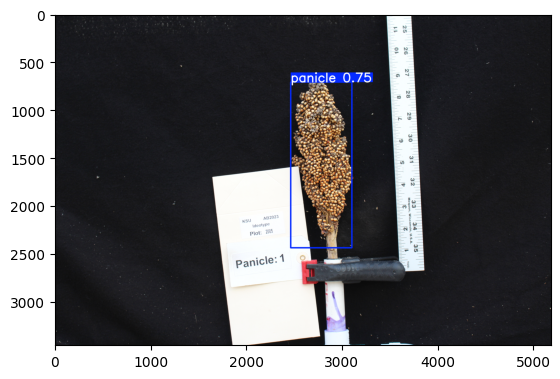

In [4]:
sample_image = os.path.join(data_path, '2005-SC964', '1. P1-WOF-Fr.jpg')
model = YOLO(weights_path)  # load a custom model
results = model(sample_image, imgsz=640, max_det = 30, conf = 0.25)
fig = plt.figure()
detect_img = results[0].plot()
detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
plt.imshow(detect_img)

In [5]:
results[0].boxes.xywh

tensor([[2777.5679, 1575.5664,  638.6858, 1729.5819]], device='cuda:0')

In [6]:
# Make a pandas dataframe
# the script is creating empty dataframe and take imformation form the Panicle Image Folder
df = pd.DataFrame(columns=['id', 'image_name', 'rep', 'height_pixels','width_pixels'])
# get the ids
# id_folder = r"annotated_panicles_lab"
id_folder = os.path.join("..", "..", "..", "sample_data", "annotated_panicles_lab")
data = []
for root, dirs, files in os.walk(id_folder):
    folder_name = os.path.basename(root)
    for file in files:
        if (file.endswith('jpg'.lower()) and 'Fr' in file):
            if 'P1' in file:                
                data.append([folder_name, file, 1])
df[['id', 'image_name', 'rep']] = data
df = df[df['id']!=os.path.basename(id_folder)].reset_index(drop=True)
df

,id,image_name,rep,height_pixels,width_pixels
0,2005-SC964,1. P1-WOF-Fr.jpg,1,NaN,NaN
1,2009-RTx430BL,1. P1-WOF-Fr.jpg,1,NaN,NaN
2,2013-Tx7000,1. P1-WOF-Fr.jpg,1,NaN,NaN


In [7]:
# Initialize an empty list to store results
output_dir = r'predicted_outputs'

# Make a pandas dataframe
for root, dirs, files in os.walk(data_path):
    folder_name = os.path.basename(root)
    if folder_name == os.path.basename(data_path):
        continue
    # Create a corresponding output folder for this subfolder
    folder_output_dir = os.path.join(output_dir, folder_name)
    os.makedirs(folder_output_dir, exist_ok=True)
    image_folder_path = os.path.join(data_path, folder_name)
    images = [f for f in files if (f.endswith('JPG'.lower()) and ('Fr' in f) and ('P1' in f))] # filter images
    if not images:
        continue # if there are no image in the folder, then continue loop
    annotations = [f for f in files if f.endswith('.json'.lower())] # filter annotations
    images.sort()
    annotations.sort()
    for idx, img in enumerate(images):
        ann = annotations[idx]
        img_path = os.path.join(image_folder_path, img)
        ann_path = os.path.join(image_folder_path, ann)

        # Perform inference
        result = model(img_path, imgsz=640, max_det=30, conf=0.40, show_labels=False, show_conf=False)
        
        # Extract the bounding boxes
        boxes = result[0].boxes.xywh.cpu().numpy()[0]  # Convert tensor to NumPy array for compatibility
        height_pixels = boxes[3]
        width_pixels = boxes[2]
        df.loc[(df['id']==folder_name) & (df['image_name']==img), 'height_pixels'] = height_pixels
        df.loc[(df['id']==folder_name) & (df['image_name']==img), 'width_pixels'] = width_pixels
        
        # Draw the bounding boxes on the image
        detect_img = result[0].plot()
        
        # Save the image with bounding boxes
        output_image_path = os.path.join(folder_output_dir, img)
        cv2.imwrite(output_image_path, detect_img)
df


image 1/1 c:\Users\choto\OneDrive - Kansas State University\PhD Projects\Agronomy\DL_for_Sorghum_Yield_Prediction\codes\2_panicle_area\3_area_from_predicted_bboxes\..\..\..\sample_data\annotated_panicles_lab\2005-SC964\1. P1-WOF-Fr.jpg: 448x640 1 panicle, 35.0ms
Speed: 3.6ms preprocess, 35.0ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\Users\choto\OneDrive - Kansas State University\PhD Projects\Agronomy\DL_for_Sorghum_Yield_Prediction\codes\2_panicle_area\3_area_from_predicted_bboxes\..\..\..\sample_data\annotated_panicles_lab\2009-RTx430BL\1. P1-WOF-Fr.jpg: 448x640 1 panicle, 35.6ms
Speed: 2.5ms preprocess, 35.6ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\Users\choto\OneDrive - Kansas State University\PhD Projects\Agronomy\DL_for_Sorghum_Yield_Prediction\codes\2_panicle_area\3_area_from_predicted_bboxes\..\..\..\sample_data\annotated_panicles_lab\2013-Tx7000\1. P1-WOF-Fr.jpg: 448x640 1 panicle, 36.4ms
Speed: 3.3

,id,image_name,rep,height_pixels,width_pixels
0,2005-SC964,1. P1-WOF-Fr.jpg,1,1729.581909,638.685791
1,2009-RTx430BL,1. P1-WOF-Fr.jpg,1,2257.836182,473.747314
2,2013-Tx7000,1. P1-WOF-Fr.jpg,1,2327.57666,597.02417


In [8]:
# It will save right where the directory:
df.to_csv("panicle_dimension_from_yolov8_predictions.csv", index=False)